In [5]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 20.5 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 43.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 48.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 47.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 56.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



========== INFORMACIÓN DEL DATASET ==========
<class 'pandas.DataFrame'>
RangeIndex: 19499 entries, 0 to 19498
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   fecha   19499 non-null  str  
 1   1       19498 non-null  str  
 2   2       19498 non-null  str  
 3   3       19498 non-null  str  
 4   4       19498 non-null  str  
dtypes: str(5)
memory usage: 761.8 KB

========== PRIMERAS FILAS ==========
        fecha  1    2     3    4
0  18/03/1961  0  5.6  31.5    7
1  19/03/1961  0  5.5    33  7.5
2  20/03/1961  0    7    34    8
3  21/03/1961  0  6.4    35    8
4  22/03/1961  0  6.3    35    7

========== ESTADÍSTICAS ==========
             fecha      1      2      3      4
count        19499  19498  19498  19498  19498
unique       19499    493    135     60     63
top     18/03/1961      0      3     35     23
freq             1  16018    401   1976   1225

 unique = valores únicos
 top = valor más repetido
 freq = cuánta

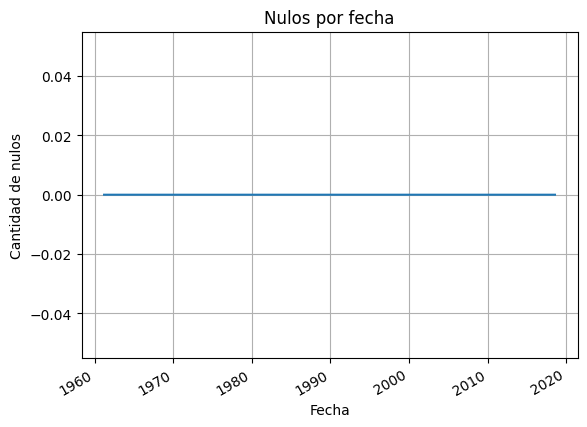


========== DATOS FINALES ==========
     fecha    1    2    3    4  nulos_por_fila
1961-03-18    0  5.6 31.5    7               0
1961-03-19    0  5.5   33  7.5               0
1961-03-20    0    7   34    8               0
1961-03-21    0  6.4   35    8               0
1961-03-22    0  6.3   35    7               0
1961-03-23    0  6.5   34    6               0
1961-03-24    0  4.3   31  7.5               0
1961-03-25    0  4.4   31   12               0
1961-03-26    0  6.3   32 10.5               0
1961-03-27    0  5.9   33 11.5               0
1961-03-28    0  5.1 32.5 10.5               0
1961-03-29    0  3.6   32   10               0
1961-03-30    0  5.6 30.5 16.5               0
1961-03-31    0  5.8 33.5  8.5               0
1961-04-01    0  6.6   32 11.5               0
1961-04-02    0  4.8 30.5    9               0
1961-04-03  9.6  5.9   30   10               0
1961-04-04    0  1.7   27 17.5               0
1961-04-05    0  6.7 29.5   15               0
1961-04-06    0  6.2   

/tmp/ipykernel_2419/529167903.py:104: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(b.head(200).round(2).to_string(index=False))


In [1]:


import pandas as pd #!pip install pandas con eso instalas pandas


import matplotlib.pyplot as plt#pip install matplotlib con eso se instala


#Configuración de visualización

pd.set_option('display.max_rows', 200)#Permite mostrar hasta 200 filas cuando imprimes un DataFrame.
pd.set_option('display.max_columns', None)#Muestra todas las columnas, sin límite.
pd.set_option('display.width', 1000)# Ajusta el ancho total de la salida en consola a 1000 caracteres.

# Cargar datos

b = pd.read_csv(
    '25001.csv',
    encoding='latin1',
    skiprows=95,
    sep=r'\s+',
    header=None
)

# Renombrar columnas
#Cambia el nombre de la columna 0 por fecha directamente en el DataFrame b.
b.rename(columns={0: 'fecha'}, inplace=True)



#Código EDA

print("\n========== INFORMACIÓN DEL DATASET ==========")
b.info()

print("\n========== PRIMERAS FILAS ==========")
print(b.head())

print("\n========== ESTADÍSTICAS ==========")
print(b.describe())

print("\n unique = valores únicos")
print(" top = valor más repetido")
print(" freq = cuántas veces aparece")



#Valores nulos

print("\n========== VALORES NULOS POR COLUMNA ==========")
print(b.isnull().sum())


# Transforma los valores de la columna fecha a fechas reales

b['fecha'] = pd.to_datetime(b['fecha'], errors='coerce', dayfirst=True)


#Contar nulos por fila

b['nulos_por_fila'] = b.isnull().sum(axis=1)

# Agrupar por fecha
nulos_por_fecha = b.groupby('fecha')['nulos_por_fila'].sum()

print("\n========== NULOS POR FECHA ==========")
print(nulos_por_fecha)


#Rellenar nulos con la media

b.fillna(b.mean(numeric_only=True), inplace=True)

print("\n========== DESPUÉS DE RELLENAR ==========")
print(b.isnull().sum())


#Visualización

plt.figure()#Crea una nueva figura
#Sirve para asegurarte de que el gráfico que vas a dibujar no se mezcle con otros gráficos anteriores.

nulos_por_fecha.plot()#Dibuja la gráfica usando los datos de nulos_por_fecha.

plt.title("Nulos por fecha")#Agrega un título al gráfico.

plt.xlabel("Fecha")#Etiqueta el eje X como "Fecha".

plt.ylabel("Cantidad de nulos")#Etiqueta el eje Y como "Cantidad de nulos".

plt.grid()#Activa una cuadrícula en el gráfico.

plt.show()# Muestra la gráfica en pantalla.


#Ordenar datos

b = b.sort_values(by='fecha')


#Mostrar datos finales

print("\n========== DATOS FINALES ==========")

# Redondear y mostrar como tabla alineada
print(b.head(200).round(2).to_string(index=False))

